# 06 — جودة القواعد واستقرارها الإحصائي

لا تكفي قوة Support أوConfidence أوLift لإثبات أن القاعدة مستقرة أو مفيدة. يعرض هذا Notebook Bootstrap transaction resampling، وعدم اليقين، والأعلام المضللة، وRedundancy وEvidence tiers. الاستقرار تجريبي تحت هذه البيانات والعتبات، وليس برهاناً عاماً أو سببياً.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

from src.data.paths import PROJECT_ROOT, project_path
from src.evaluation.rule_quality import build_rule_quality_outputs
from src.visualization.advanced_results import generate_advanced_figures

assert Path.cwd().resolve() == PROJECT_ROOT
assert ".venv" in sys.executable
summary = pd.read_csv(project_path("outputs", "tables", "bootstrap_summary.csv"))
metadata = pd.read_csv(project_path("outputs", "tables", "bootstrap_run_metadata.csv"))
assert len(metadata) == int(summary.loc[0, "resamples_requested"])
assert metadata.status.str.startswith("success").all()
display(summary)

,resamples_requested,resamples_completed,initial_resamples,expanded_to_30,successful_runs,failed_or_stopped_runs,total_runtime_seconds,median_runtime_seconds,maximum_runtime_seconds,minimum_support,minimum_support_count_per_sample,maximum_length,candidate_rules_evaluated,very_stable_rules,moderately_stable_rules,weakly_stable_rules,unstable_rules,seeds,expansion_decision
0,20,20,20,False,20,0,385.898251,18.875608,23.329254,0.005,90,3,3423,1911,1201,308,3,51001 | 51002 | 51003 | 51004 | 51005 | 51006 ...,Stopped at 20 because the frozen expansion cri...


## منهج Bootstrap والبذور

سُحبت كل عينة من 17,901 معاملة مع الإرجاع وبالحجم نفسه. استخدمت البذور المتسلسلة المسجلة في metadata، وMinimum Support=0.005، وsupport count=90، و`max_len=3`. تُعد القاعدة حاضرة فقط إذا عادت بالمفتاح نفسه ومرت أيضاً بـConfidence≥0.70 وLift≥1.20. تحفظ المقاييس عند إمكان توليد المفتاح حتى لو لم يمر بكل الحدود.

In [2]:
display(metadata[["resample_id", "seed", "sample_size", "unique_source_transactions", "minimum_support_count", "frequent_itemset_count", "candidate_rules_present", "runtime_seconds", "status"]])
print("Recorded seeds:", metadata.seed.tolist())

,resample_id,seed,sample_size,unique_source_transactions,minimum_support_count,frequent_itemset_count,candidate_rules_present,runtime_seconds,status
0,1,51001,17901,11293,90,17476,2563,13.667318,success
1,2,51002,17901,11332,90,17037,2403,18.473603,success
2,3,51003,17901,11371,90,18877,2574,18.148844,success
3,4,51004,17901,11308,90,20820,2938,19.924250,success
4,5,51005,17901,11291,90,23752,2841,22.298112,success
5,6,51006,17901,11313,90,16120,2326,16.182950,success
6,7,51007,17901,11350,90,26038,3095,22.214969,success
7,8,51008,17901,11323,90,15083,2343,14.814203,success
8,9,51009,17901,11320,90,20932,2658,21.990166,success
9,10,51010,17901,11307,90,24146,2874,23.033098,success


Recorded seeds: [51001, 51002, 51003, 51004, 51005, 51006, 51007, 51008, 51009, 51010, 51011, 51012, 51013, 51014, 51015, 51016, 51017, 51018, 51019, 51020]


## فئات الاستقرار وRule Presence

In [3]:
categories = pd.read_csv(project_path("outputs", "tables", "rule_stability_categories.csv"))
stability = pd.read_csv(project_path("outputs", "tables", "rule_stability_results.csv"))
display(categories)
display(stability[["rule_key", "support_count", "confidence", "lift", "rule_presence_rate", "stability_category"]].head(15))

,stability_category,rule_count,rule_percentage,category_definition
0,Very stable,1911,55.828221,presence rate >= 0.80
1,Moderately stable,1201,35.086182,0.50 <= presence rate < 0.80
2,Weakly stable,308,8.997955,0.20 <= presence rate < 0.50
3,Unstable,3,0.087642,presence rate < 0.20


,rule_key,support_count,confidence,lift,rule_presence_rate,stability_category
0,22697 => 22699,700,0.751073,14.063763,1.0,Very stable
1,22698 => 22697,576,0.820513,15.759657,1.0,Very stable
2,22698 => 22699,545,0.776353,14.537134,1.0,Very stable
3,22698 | 22699 => 22697,492,0.902752,17.339237,1.0,Very stable
4,22697 | 22698 => 22699,492,0.854167,15.994181,1.0,Very stable
5,21931 | 22386 => 85099B,405,0.801980,7.419249,1.0,Very stable
6,21931 | 22411 => 85099B,384,0.748538,6.924847,1.0,Very stable
7,22578 => 22577,368,0.768267,27.019158,1.0,Very stable
8,22386 | 22411 => 85099B,366,0.806167,7.457986,1.0,Very stable
9,22423 | 22699 => 22697,359,0.790749,15.187979,1.0,Very stable


Very stable تعني حضوراً≥0.80، وModerately stable من 0.50، وWeakly stable من 0.20، وUnstable دون 0.20. هذه حدود اصطلاحية للمشروع وليست قوانين علمية.

## عدم اليقين في المقاييس

In [4]:
uncertainty = pd.read_csv(project_path("outputs", "tables", "rule_metric_uncertainty.csv"))
display(uncertainty.head(15))
display(stability[["rule_key", "confidence_mean", "confidence_p025", "confidence_p975", "lift_mean", "lift_p025", "lift_p975"]].head(12))

,rule_key,metric,valid_observations,mean,std,p025,p975,minimum,maximum
0,21801 => 21802 | 21803,support,17,0.005458,0.000388,0.005028,0.006167,0.005028,0.006368
1,21801 => 21802 | 21803,confidence,17,0.791827,0.032866,0.742507,0.845260,0.740157,0.853211
2,21801 => 21802 | 21803,lift,17,101.990520,6.756252,90.965406,114.729322,90.309740,118.397909
3,21802 | 21803 => 21801,support,17,0.005458,0.000388,0.005028,0.006167,0.005028,0.006368
4,21802 | 21803 => 21801,confidence,17,0.701231,0.031701,0.638889,0.742583,0.627586,0.744681
5,21802 | 21803 => 21801,lift,17,101.990520,6.756252,90.965406,114.729322,90.309740,118.397909
6,23291 => 23289,support,20,0.006044,0.000566,0.005084,0.006938,0.005084,0.007150
7,23291 => 23289,confidence,20,0.752473,0.039520,0.684839,0.814057,0.679104,0.821918
8,23291 => 23289,lift,20,96.364399,7.196752,84.903315,109.925020,83.692308,112.189463
9,23289 => 23291,support,20,0.006044,0.000566,0.005084,0.006938,0.005084,0.007150


,rule_key,confidence_mean,confidence_p025,confidence_p975,lift_mean,lift_p025,lift_p975
0,22697 => 22699,0.749564,0.727045,0.778914,14.096182,13.495766,14.829179
1,22698 => 22697,0.813635,0.787884,0.833563,15.755147,14.796979,16.642285
2,22698 => 22699,0.772530,0.743117,0.803922,14.527633,13.912909,15.439662
3,22698 | 22699 => 22697,0.900228,0.878867,0.921445,17.434710,16.249029,18.516119
4,22697 | 22698 => 22699,0.854675,0.825404,0.880307,16.074157,15.304304,17.145852
5,21931 | 22386 => 85099B,0.801499,0.771856,0.824402,7.415395,7.142743,7.781929
6,21931 | 22411 => 85099B,0.744723,0.717532,0.769557,6.889413,6.631564,7.163470
7,22578 => 22577,0.768462,0.727207,0.793228,27.089897,25.316500,28.486441
8,22386 | 22411 => 85099B,0.795079,0.769133,0.826535,7.356843,6.928275,7.774279
9,22423 | 22699 => 22697,0.787035,0.751935,0.827507,15.238347,14.206353,16.288545


## Stable وUnstable examples

In [5]:
stable_examples = stability.nlargest(8, ["rule_presence_rate", "support_count"])
unstable_examples = stability.nsmallest(8, ["rule_presence_rate", "support_count"])
display(stable_examples[["rule_key", "support_count", "confidence", "lift", "rule_presence_rate", "stability_category"]])
display(unstable_examples[["rule_key", "support_count", "confidence", "lift", "rule_presence_rate", "stability_category"]])

,rule_key,support_count,confidence,lift,rule_presence_rate,stability_category
0,22697 => 22699,700,0.751073,14.063763,1.0,Very stable
1,22698 => 22697,576,0.820513,15.759657,1.0,Very stable
2,22698 => 22699,545,0.776353,14.537134,1.0,Very stable
3,22698 | 22699 => 22697,492,0.902752,17.339237,1.0,Very stable
4,22697 | 22698 => 22699,492,0.854167,15.994181,1.0,Very stable
5,21931 | 22386 => 85099B,405,0.801980,7.419249,1.0,Very stable
6,21931 | 22411 => 85099B,384,0.748538,6.924847,1.0,Very stable
7,22578 => 22577,368,0.768267,27.019158,1.0,Very stable


,rule_key,support_count,confidence,lift,rule_presence_rate,stability_category
3422,22446 => 22961,90,0.725806,12.889545,0.10,Unstable
3421,22697 | 85131D => 85131B,92,0.702290,73.091248,0.10,Unstable
3420,23300 | 23344 => 23301,90,0.731707,14.586072,0.15,Unstable
3419,21990 | 21991 => 21993,94,0.712121,31.244318,0.20,Weakly stable
3418,22086 | 22727 => 22910,106,0.701987,15.707831,0.20,Weakly stable
3414,22371 | 84032A => 21935,90,0.891089,31.462300,0.25,Weakly stable
3415,21993 | 22698 => 22697,90,0.857143,16.463213,0.25,Weakly stable
3416,22371 | 22697 => 21935,90,0.825688,29.153140,0.25,Weakly stable


## Misleading-rule detection وRedundancy

In [6]:
quality_result = build_rule_quality_outputs()
flags = pd.read_csv(project_path("outputs", "tables", "misleading_rule_flags.csv"))
redundant = pd.read_csv(project_path("outputs", "tables", "redundant_rules.csv"))
display(pd.DataFrame([quality_result]))
display(flags)
display(redundant.head(12))

,rules_evaluated,rules_with_any_flag,redundant_rules,nonredundant_stable_rules,final_interpretation_candidates,tier_a,tier_b,tier_c,tier_d
0,3423,2802,255,2871,2871,590,2281,549,3


,flag,rule_count,rule_percentage
0,high_lift_low_count,2082,60.823839
1,near_support_floor,1975,57.697926
2,common_consequent,646,18.872334
3,weak_bootstrap_stability,311,9.085597
4,reciprocal_rule_exists,54,1.577564
5,insufficient_business_evidence,3,0.087642
6,equivalent_normalized_code,0,0.000000
7,high_confidence_weak_lift,0,0.000000
8,wide_confidence_interval,0,0.000000
9,wide_lift_interval,0,0.000000


,rule_key,simpler_rule_key,antecedent_length,simpler_antecedent_length,confidence,simpler_confidence,absolute_confidence_difference,lift,simpler_lift,relative_lift_gain,is_redundant,criterion
0,22720 | 23300 => 23301,23300 => 23301,2,1,0.721429,0.721333,0.000095,14.381172,14.379274,0.000132,True,abs confidence difference <= 0.05; relative li...
1,21314 | 22697 => 22699,22697 => 22699,2,1,0.751553,0.751073,0.000480,14.072747,14.063763,0.000639,True,abs confidence difference <= 0.05; relative li...
2,22697 | 82580 => 22699,22697 => 22699,2,1,0.751553,0.751073,0.000480,14.072747,14.063763,0.000639,True,abs confidence difference <= 0.05; relative li...
3,22423 | 23171 => 23170,23171 => 23170,2,1,0.836879,0.836310,0.000570,39.320154,39.293377,0.000681,True,abs confidence difference <= 0.05; relative li...
4,23171 | 23245 => 23170,23171 => 23170,2,1,0.836879,0.836310,0.000570,39.320154,39.293377,0.000681,True,abs confidence difference <= 0.05; relative li...
5,22197 | 22698 => 22697,22698 => 22697,2,1,0.821192,0.820513,0.000679,15.772703,15.759657,0.000828,True,abs confidence difference <= 0.05; relative li...
6,21928 | 22697 => 22699,22697 => 22699,2,1,0.751773,0.751073,0.000700,14.076872,14.063763,0.000932,True,abs confidence difference <= 0.05; relative li...
7,22379 | 22697 => 22699,22697 => 22699,2,1,0.752747,0.751073,0.001674,14.095114,14.063763,0.002229,True,abs confidence difference <= 0.05; relative li...
8,21993 | 85131B => 85131D,85131B => 85131D,2,1,0.798319,0.796512,0.001808,69.372399,69.215314,0.002270,True,abs confidence difference <= 0.05; relative li...
9,22086 | 22579 => 22578,22579 => 22578,2,1,0.850877,0.848387,0.002490,31.798649,31.705590,0.002935,True,abs confidence difference <= 0.05; relative li...


توضح الأعلام حالات مثل Lift مرتفع قرب floor أو Consequent شائع أو استقرار ضعيف؛ لا تعلن تلقائياً بطلان القاعدة. تعد القاعدة الأطول redundant فقط إذا وجدت قاعدة أبسط لنفس Consequent بفارق Confidence≤0.05 ومن دون تحسن Lift يتجاوز 10%.

## Evidence tiers والمرشحون النهائيون

In [7]:
tiers = pd.read_csv(project_path("outputs", "tables", "rule_evidence_tiers.csv"))
final_candidates = pd.read_csv(project_path("outputs", "tables", "final_interpretation_candidates.csv"))
display(tiers)
display(final_candidates[["rule_key", "support_count", "confidence", "lift", "rule_presence_rate", "evidence_tier", "recommended_disposition", "quality_flags"]].head(15))

,evidence_tier,rule_count,rule_percentage
0,Tier A,590,17.236342
1,Tier B,2281,66.637453
2,Tier C,549,16.038563
3,Tier D,3,0.087642


,rule_key,support_count,confidence,lift,rule_presence_rate,evidence_tier,recommended_disposition,quality_flags
0,22697 => 22699,700,0.751073,14.063763,1.0,Tier A,retain,reciprocal_rule_exists
1,22698 => 22697,576,0.820513,15.759657,1.0,Tier A,retain,none
2,22698 => 22699,545,0.776353,14.537134,1.0,Tier A,retain,none
3,22698 | 22699 => 22697,492,0.902752,17.339237,1.0,Tier A,retain,none
4,22697 | 22698 => 22699,492,0.854167,15.994181,1.0,Tier A,retain,none
5,21931 | 22386 => 85099B,405,0.801980,7.419249,1.0,Tier A,retain,common_consequent
6,21931 | 22411 => 85099B,384,0.748538,6.924847,1.0,Tier A,retain,common_consequent
7,22578 => 22577,368,0.768267,27.019158,1.0,Tier A,retain,reciprocal_rule_exists
8,22386 | 22411 => 85099B,366,0.806167,7.457986,1.0,Tier A,retain,common_consequent
9,22423 | 22699 => 22697,359,0.790749,15.187979,1.0,Tier A,retain,none


## Corrected scalability

In [8]:
scalability = pd.read_csv(project_path("outputs", "comparisons", "scalability_protocol_summary.csv"))
display(scalability[["protocol", "subset_fraction", "algorithm", "support_proportion", "support_count", "median_runtime_seconds", "median_itemset_count"]])

,protocol,subset_fraction,algorithm,support_proportion,support_count,median_runtime_seconds,median_itemset_count
0,A_fixed_support_proportion,0.25,Apriori,0.005000,23,12.643483,20480.0
1,A_fixed_support_proportion,0.25,FP-Growth,0.005000,23,7.362619,20480.0
2,A_fixed_support_proportion,0.50,Apriori,0.005000,45,18.697545,18825.0
3,A_fixed_support_proportion,0.50,FP-Growth,0.005000,45,14.357820,18825.0
4,A_fixed_support_proportion,0.75,Apriori,0.005000,68,22.812871,19211.0
5,A_fixed_support_proportion,0.75,FP-Growth,0.005000,68,19.493521,19211.0
6,A_fixed_support_proportion,1.00,Apriori,0.005000,90,16.552388,18681.0
7,A_fixed_support_proportion,1.00,FP-Growth,0.005000,90,11.104805,18681.0
8,B_fixed_absolute_support_count,0.25,Apriori,0.020112,90,0.683661,412.0
9,B_fixed_absolute_support_count,0.25,FP-Growth,0.020112,90,1.002442,412.0


Protocol A يثبت النسبة فتتغير قيمة count، بينما Protocol B يثبت count=90 فتتغير النسبة. يستخدم كلاهما ثلاثة random seeds للكسور دون 100% والصفوف نفسها للخوارزميتين. لا يحذف ذلك anomaly الأصلي؛ بل يفسره بوصفه أثراً للحد العددي والتركيب الزمني.

## رسوم متقدمة مختارة

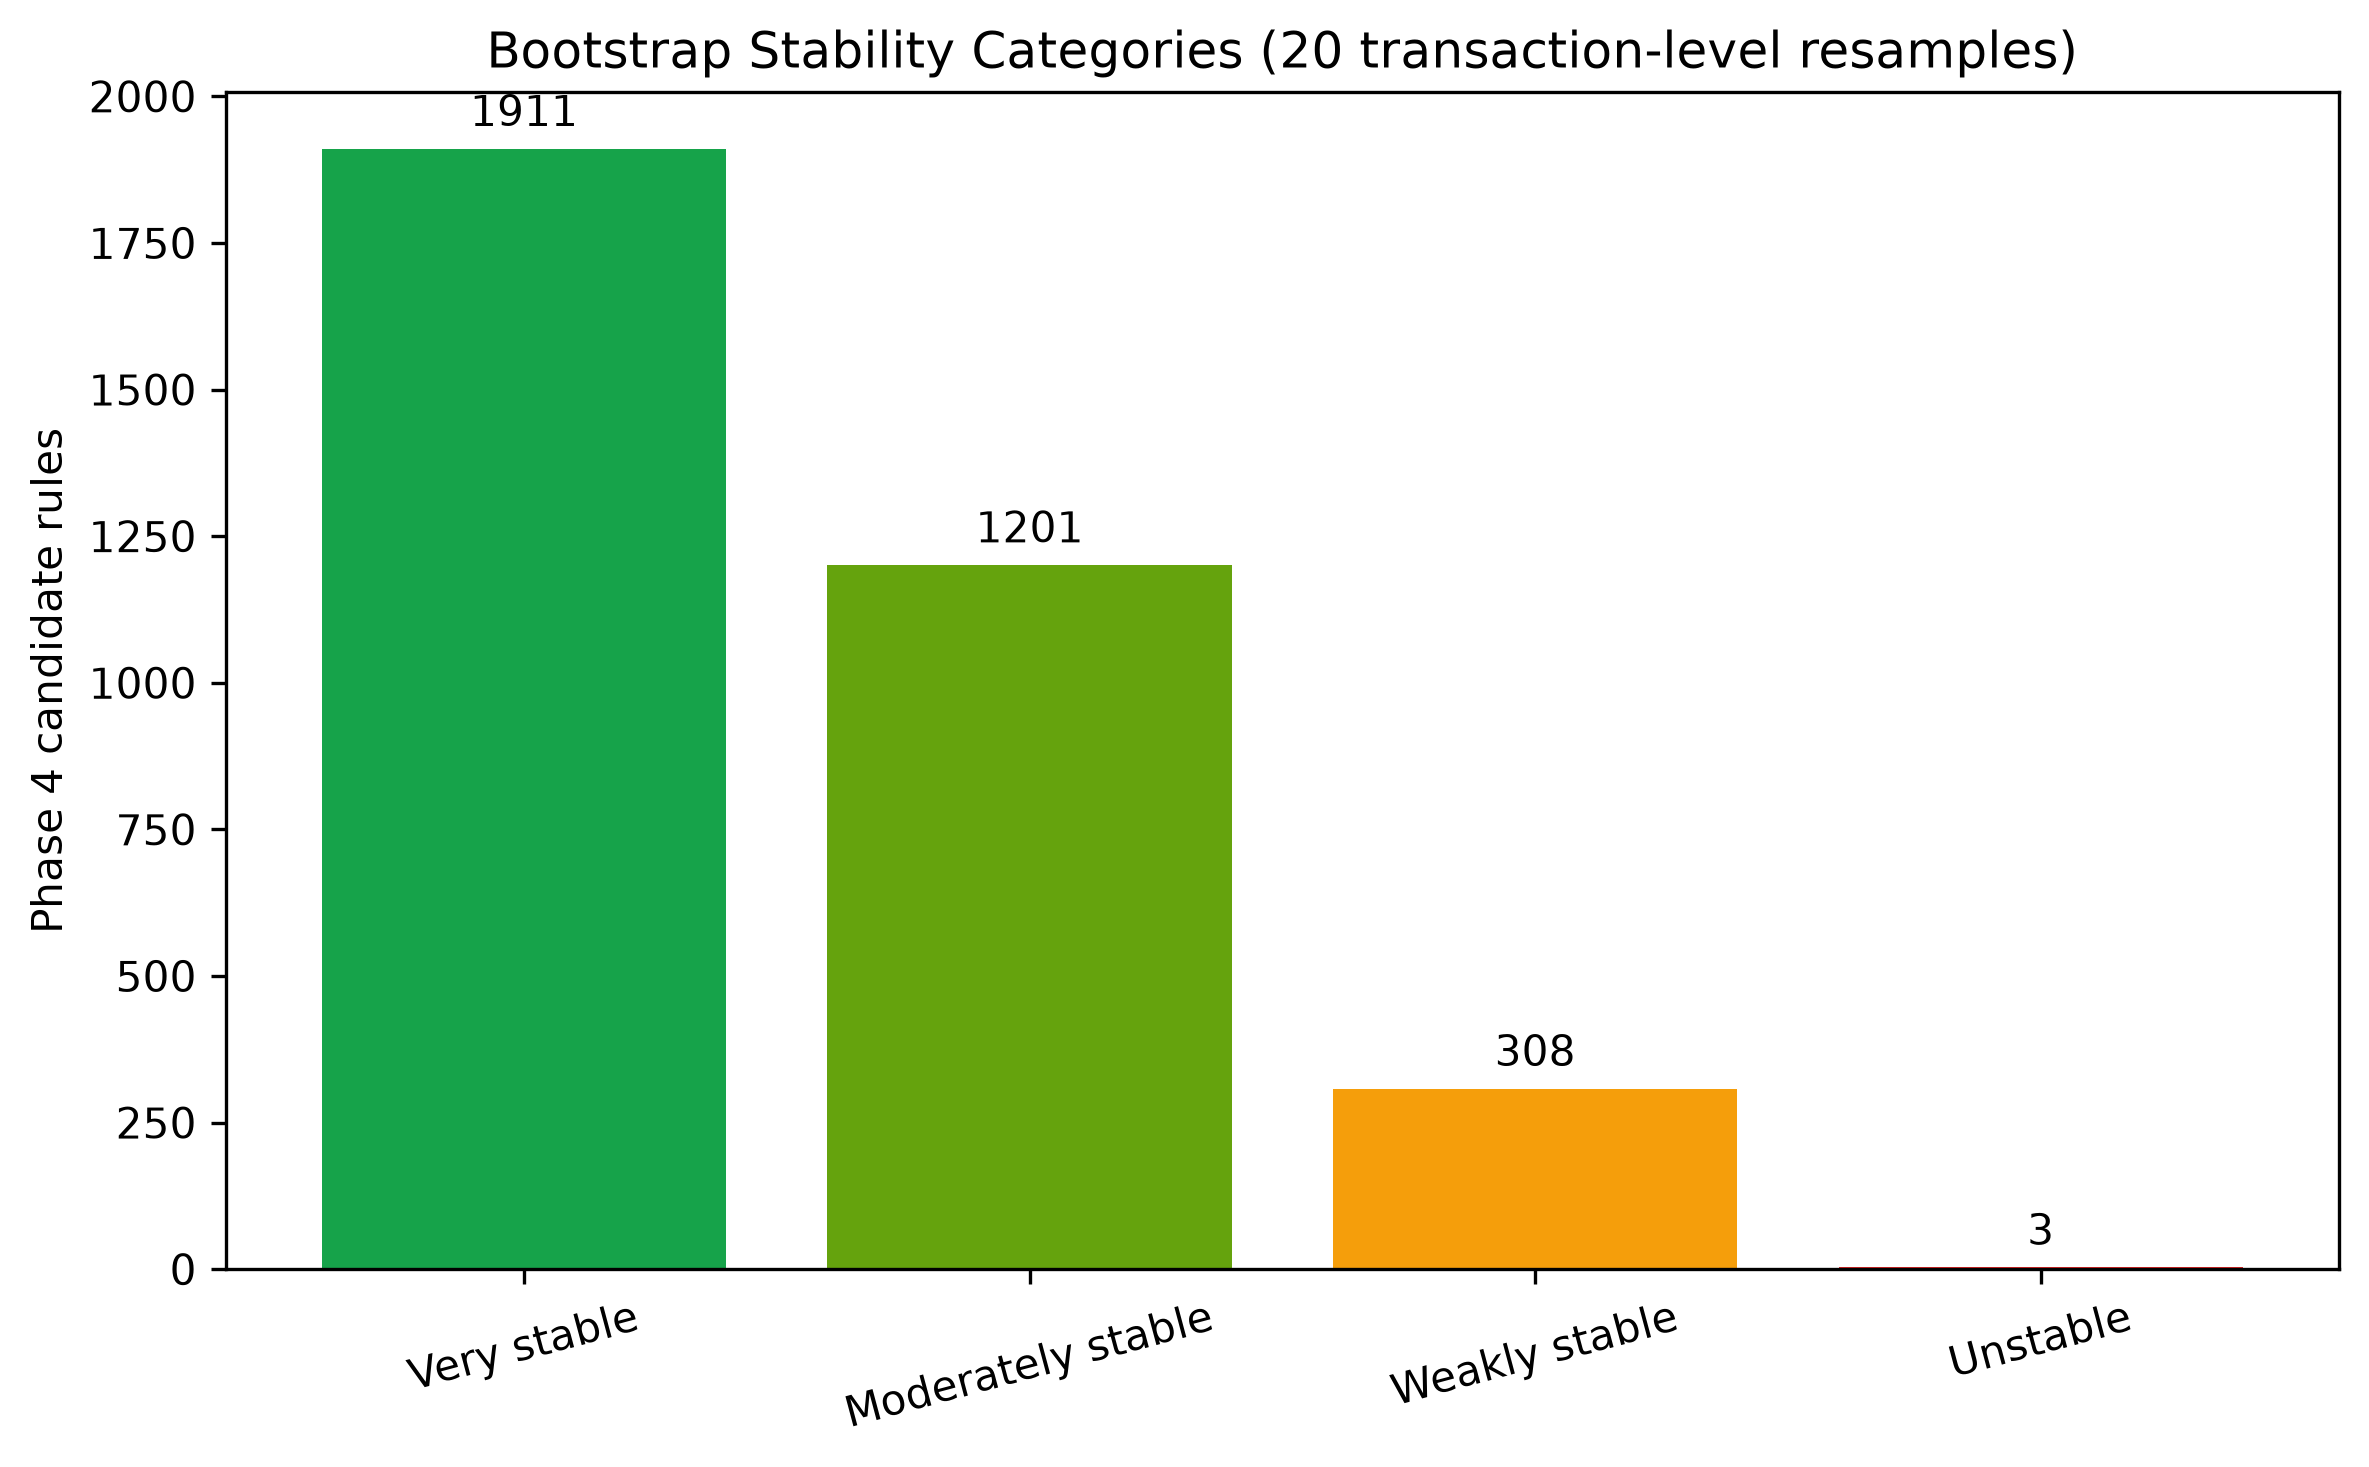

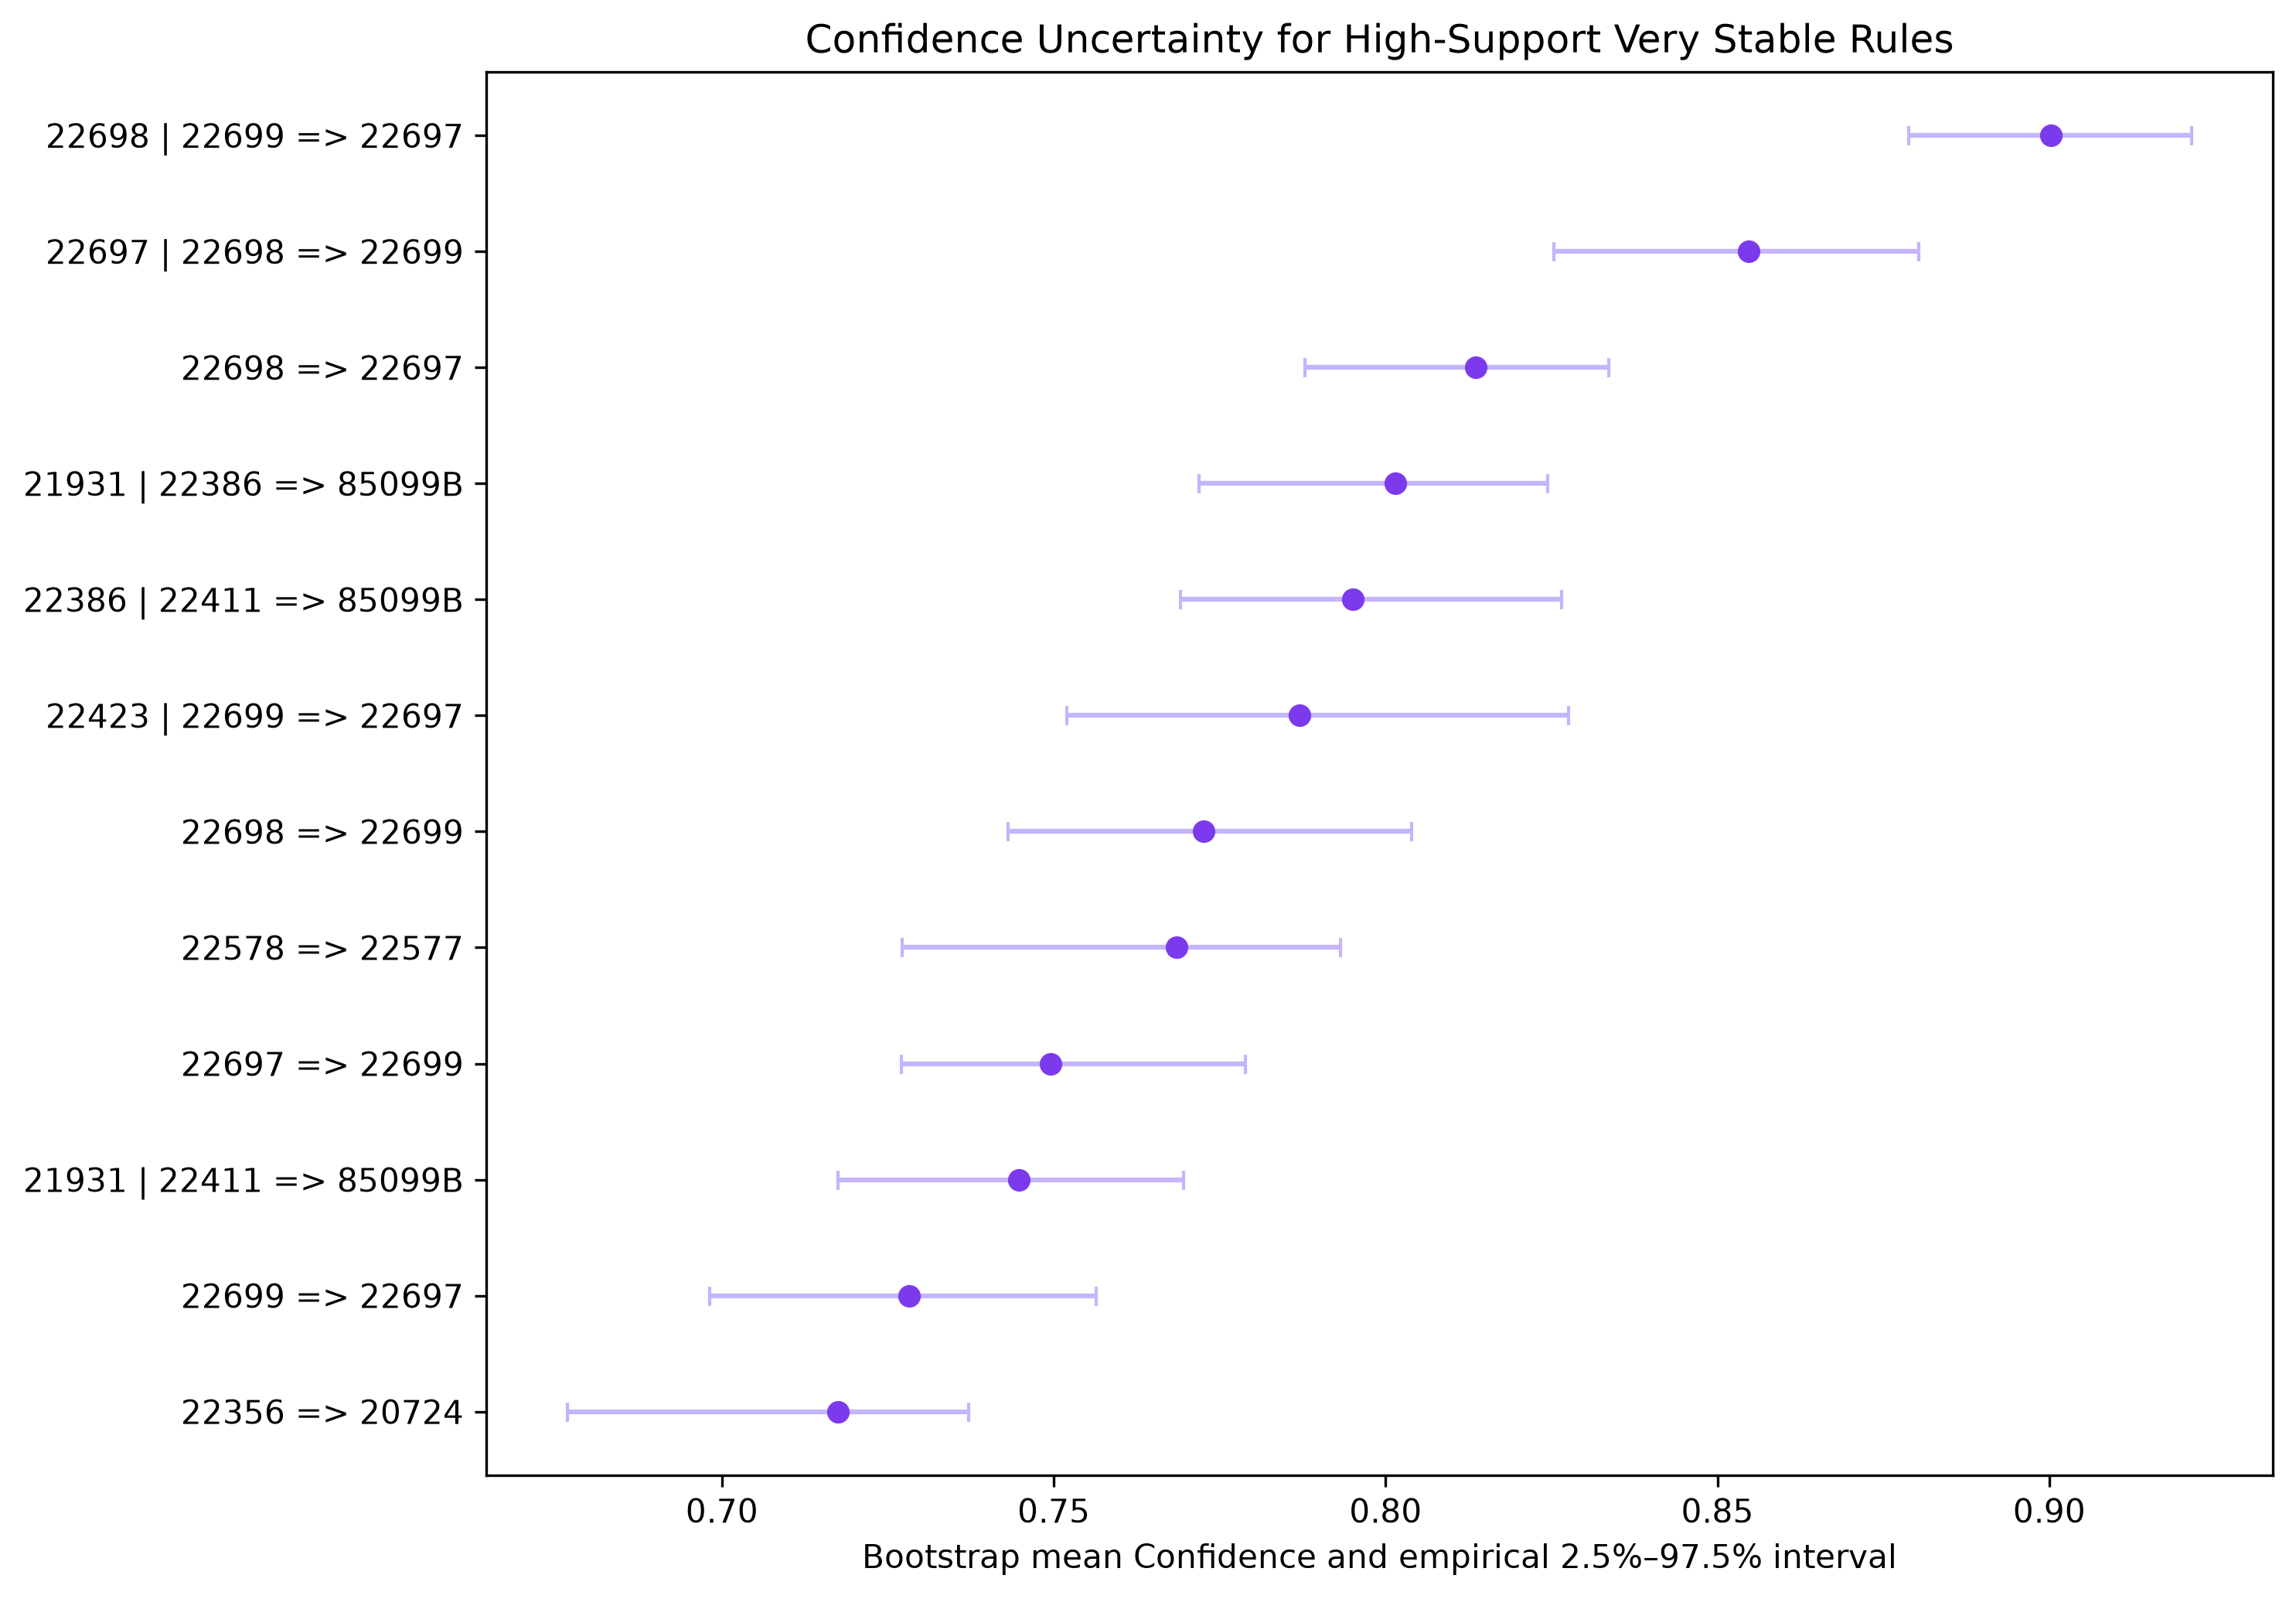

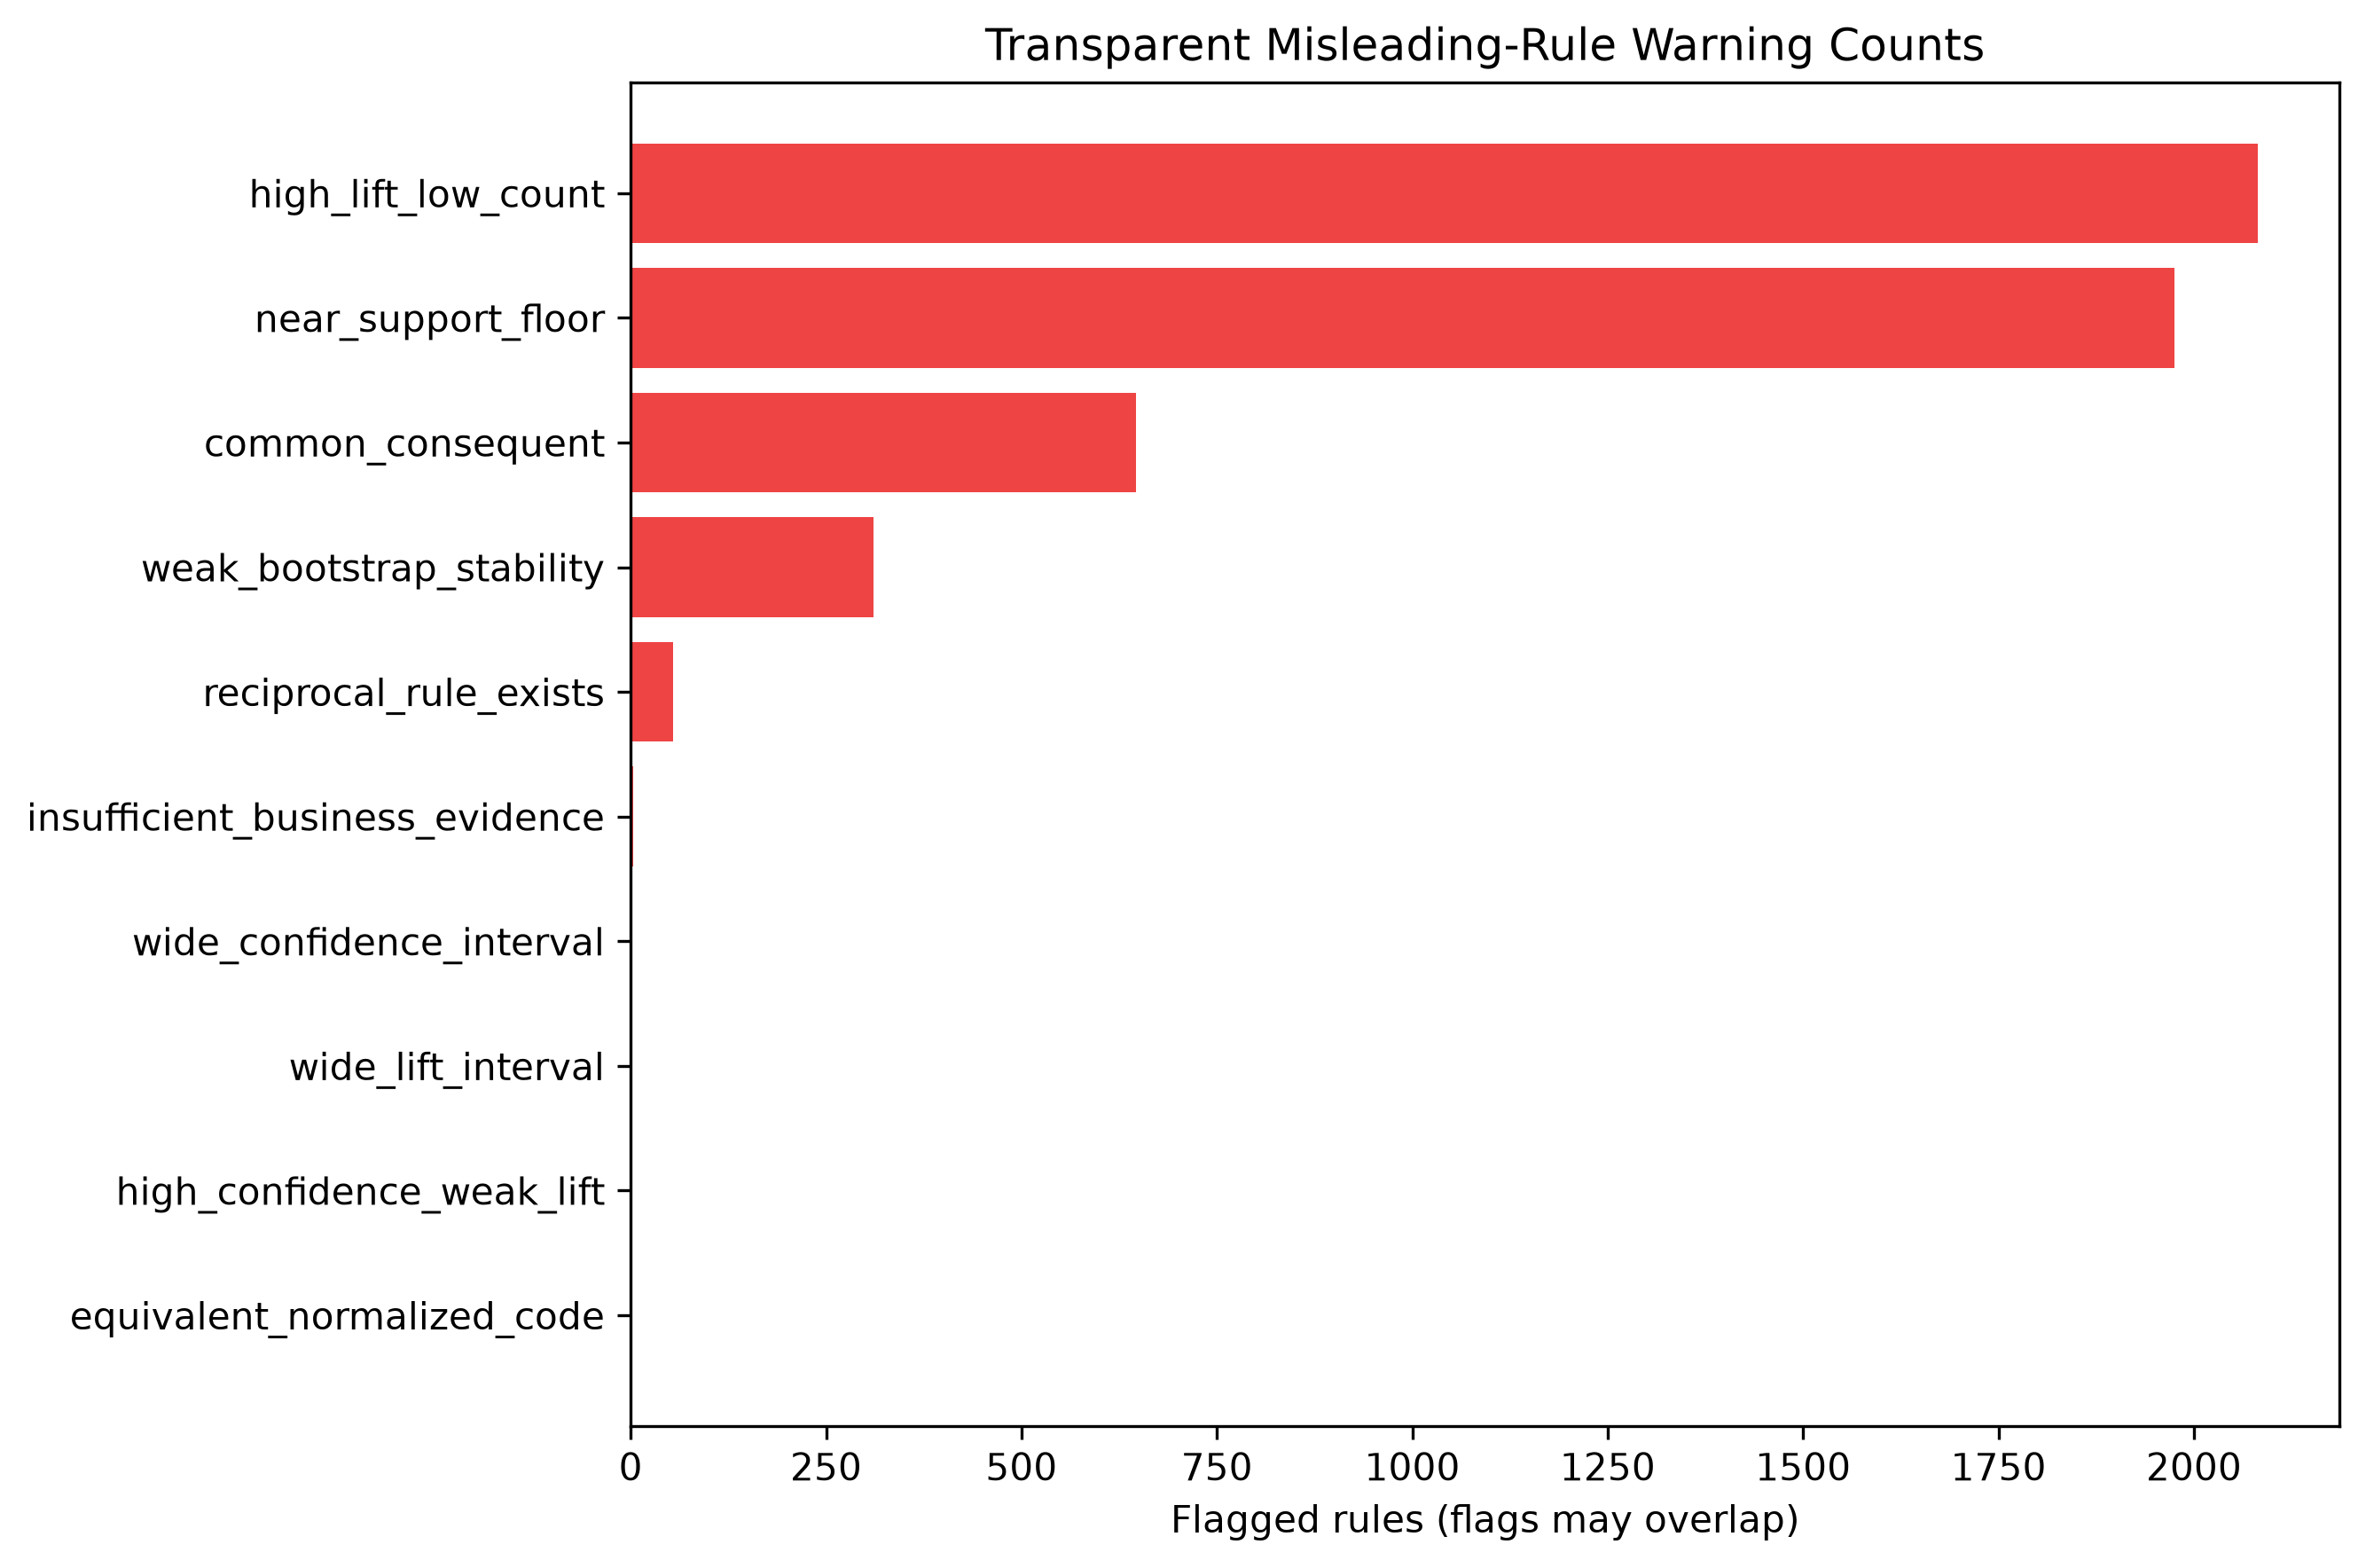

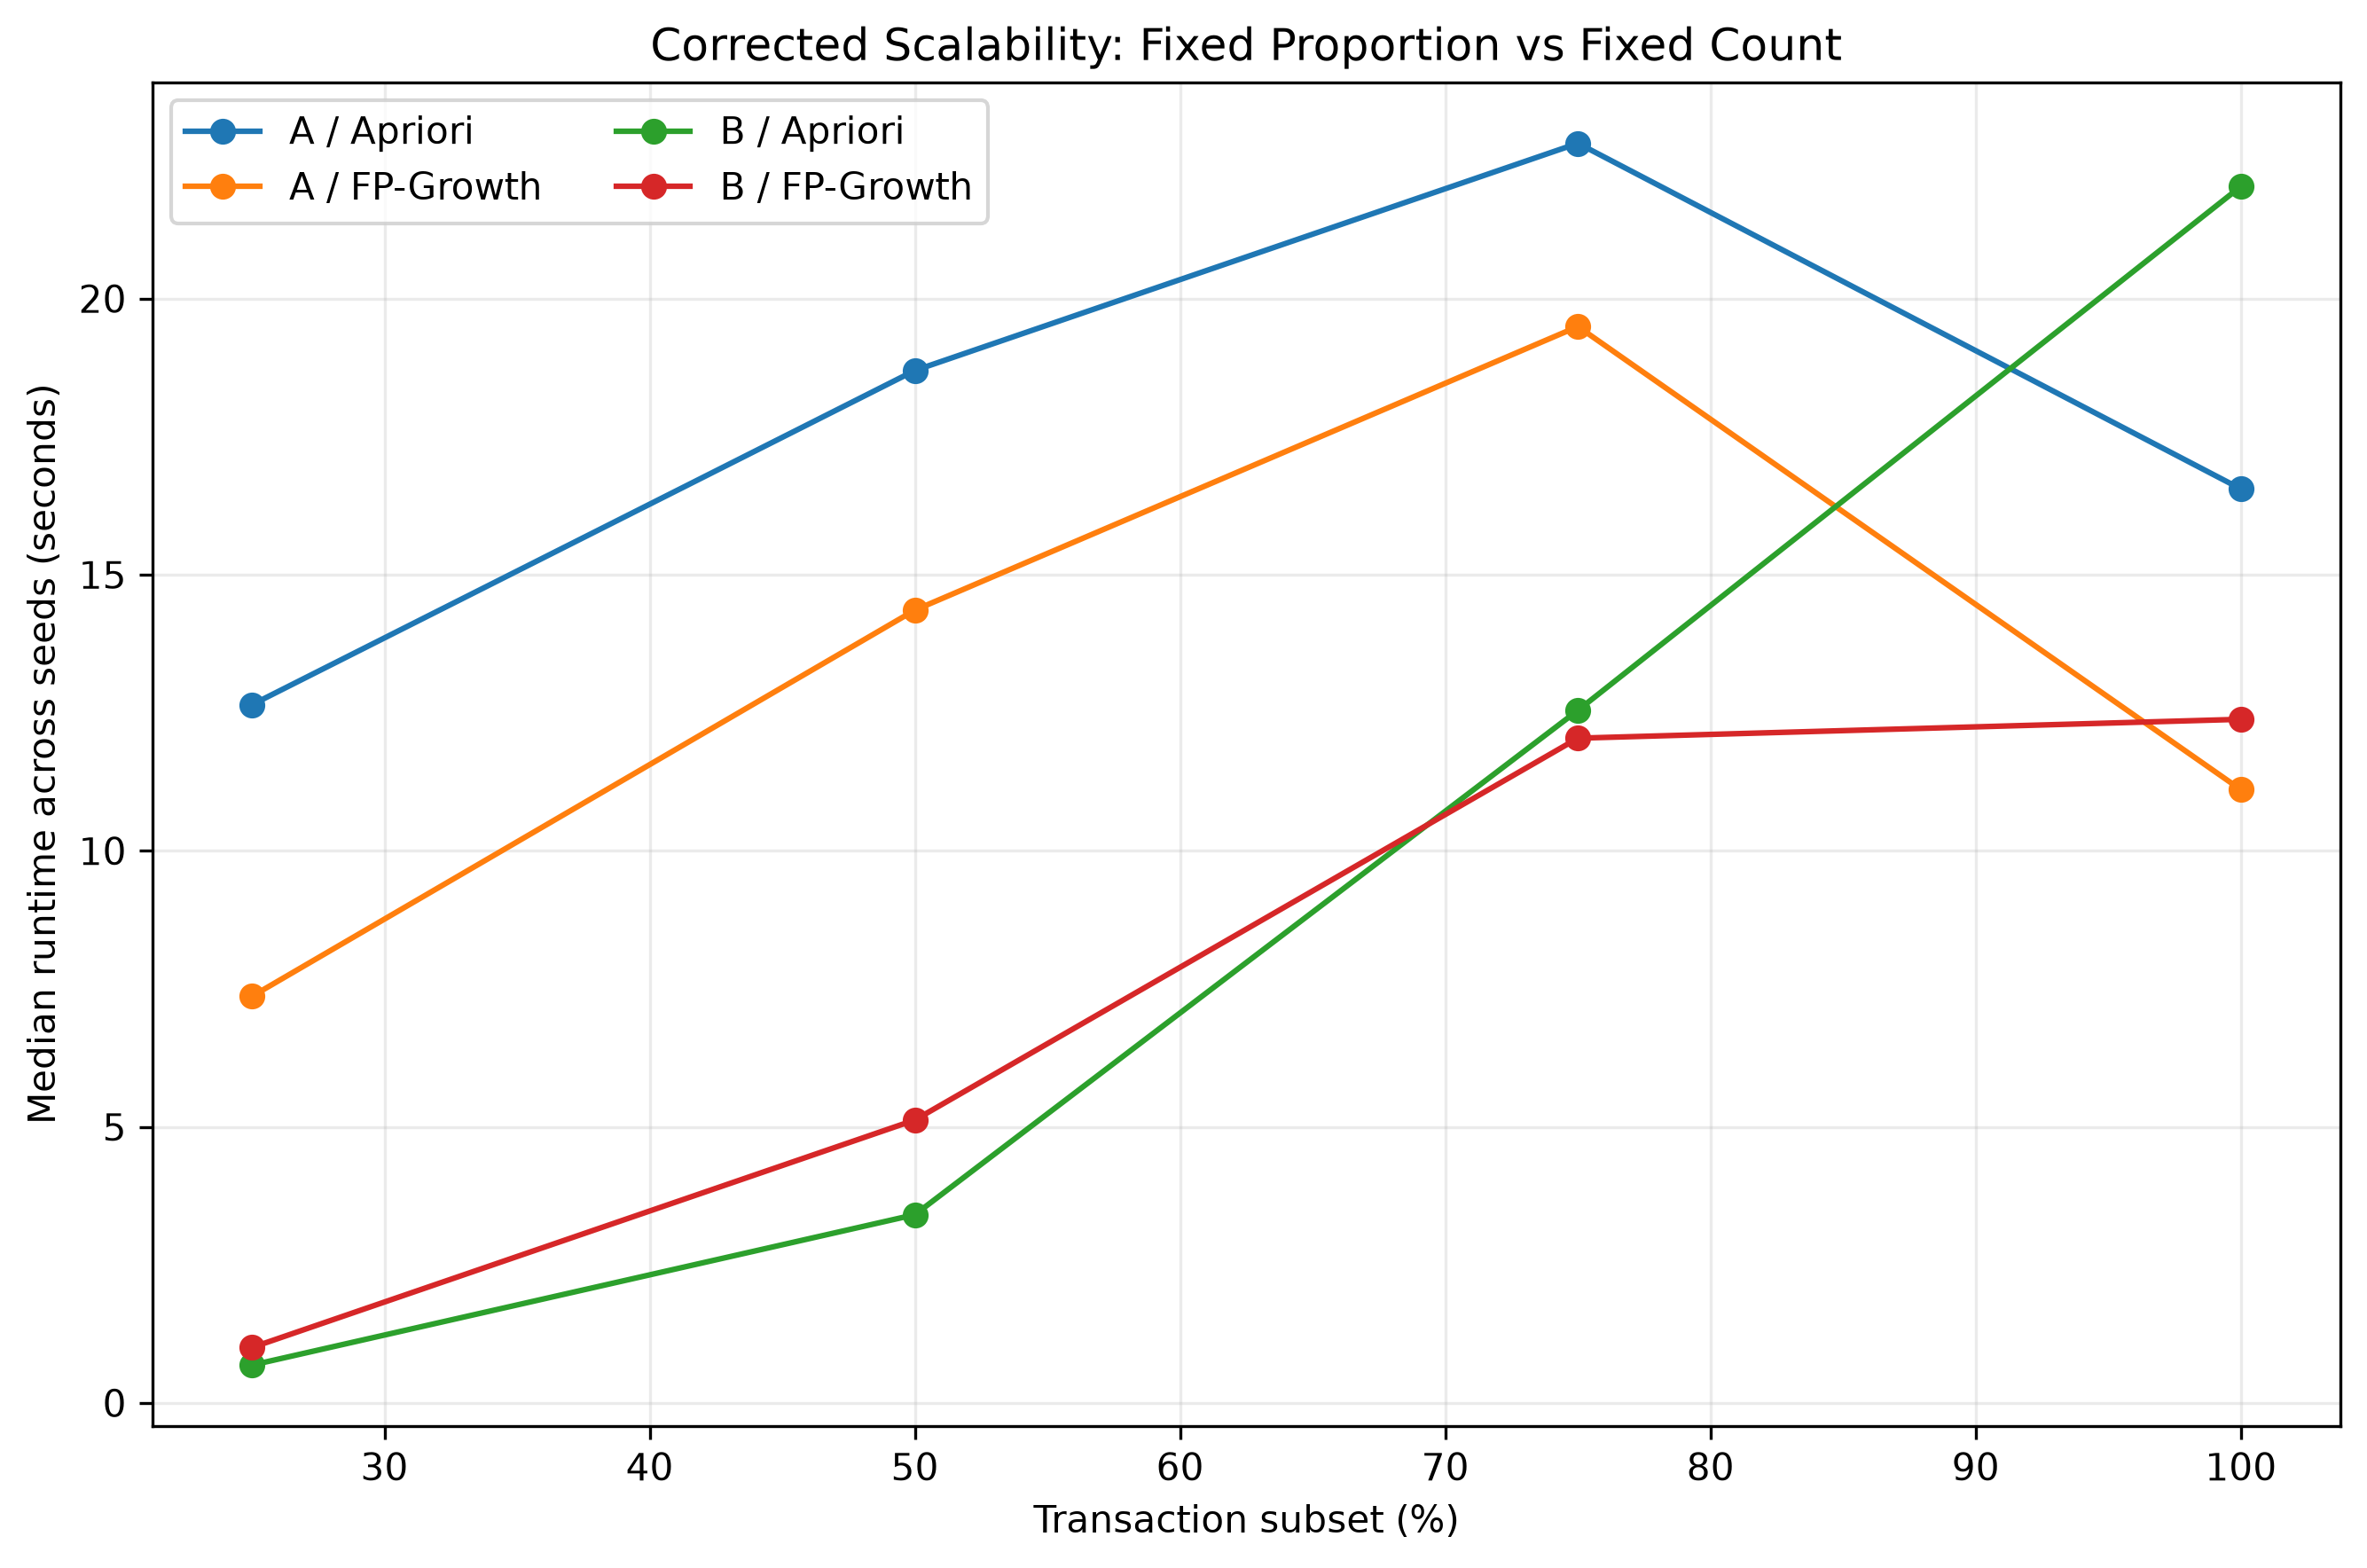

In [9]:
generate_advanced_figures()
for filename in [
    "rule_stability_category_distribution.png",
    "confidence_uncertainty_top_stable_rules.png",
    "misleading_rule_flag_counts.png",
    "corrected_scalability_comparison.png",
]:
    display(Image(filename=str(project_path("outputs", "figures", filename)), width=900))

## القيود

Bootstrap يعيد أخذ العينات من dataset نفسه ولا يثبت الصلاحية خارجياً. الفواصل empirical وليست ضمانات سكانية، و20 resamples تعطي دقة محدودة لمعدل الحضور. لم تنفذ WEKA أو سببية أو اختبار أثر تجاري.